In [8]:
import pandas as pd

boston_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
boston_df=pd.read_csv(boston_url)


Task 1
Become familiar with th dataset

In [9]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


Task 2.1
For the "Median value of owner-occupied homes" provide a boxplot

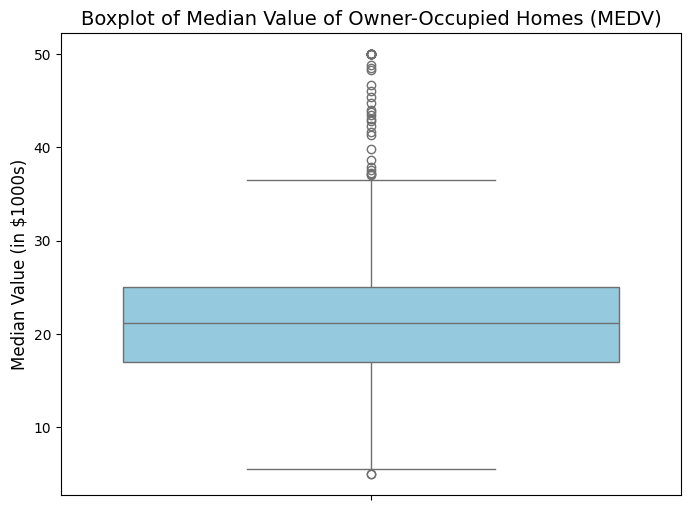

Q1 (25th percentile): 17.0250
Median (Q2, 50th percentile): 21.2000
Q3 (75th percentile): 25.0000
IQR (Interquartile Range): 7.9750
Lower Whisker: 5.0625
Upper Whisker: 36.9625


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(8, 6))
sns.boxplot(y=boston_df['MEDV'], color='skyblue')
plt.title('Boxplot of Median Value of Owner-Occupied Homes (MEDV)', fontsize=14)
plt.ylabel('Median Value (in $1000s)', fontsize=12)
plt.show()

Q1 = boston_df['MEDV'].quantile(0.25)
Q2 = boston_df['MEDV'].median()  
Q3 = boston_df['MEDV'].quantile(0.75) 
IQR = Q3 - Q1                        

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR


print(f"Q1 (25th percentile): {Q1:.4f}")
print(f"Median (Q2, 50th percentile): {Q2:.4f}")
print(f"Q3 (75th percentile): {Q3:.4f}")
print(f"IQR (Interquartile Range): {IQR:.4f}")
print(f"Lower Whisker: {lower_whisker:.4f}")
print(f"Upper Whisker: {upper_whisker:.4f}")


Task 2.2 Provide a bar plot for the Charles river variable

C:\Users\adeli\AppData\Local\Temp\ipykernel_11296\3097012904.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chas_counts.index, y=chas_counts.values, palette='viridis')


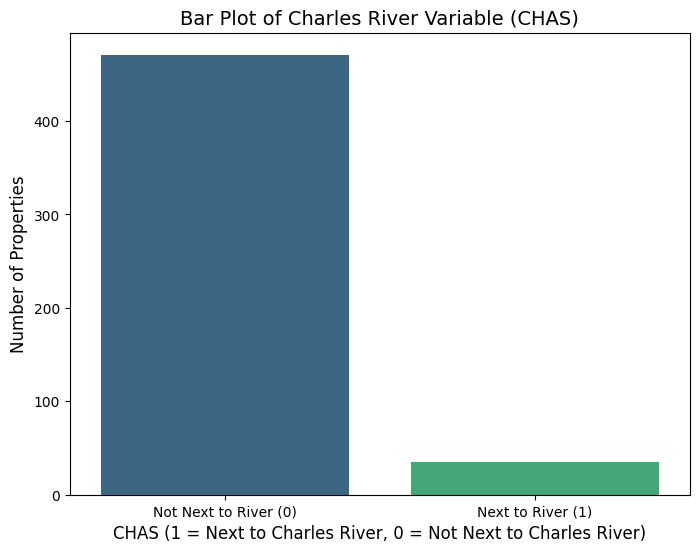

In [14]:
chas_counts = boston_df['CHAS'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=chas_counts.index, y=chas_counts.values, palette='viridis')
plt.title('Bar Plot of Charles River Variable (CHAS)', fontsize=14)
plt.xlabel('CHAS (1 = Next to Charles River, 0 = Not Next to Charles River)', fontsize=12)
plt.ylabel('Number of Properties', fontsize=12)
plt.xticks([0, 1], ['Not Next to River (0)', 'Next to River (1)'])
plt.show()

Most of the houses are not next to the Charles river

Task 2.3 Provide a boxplot for the MEDV variable vs the AGE variable. (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

C:\Users\adeli\AppData\Local\Temp\ipykernel_11296\2892403437.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df, palette='pastel')


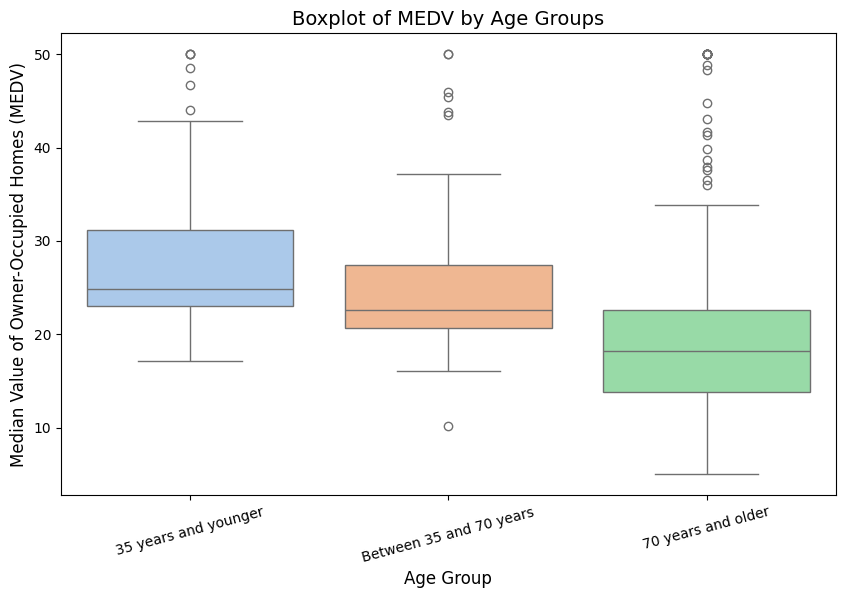

In [15]:
boston_df['AGE_GROUP'] = pd.cut(
    boston_df['AGE'],
    bins=[0, 35, 70, 100],
    labels=['35 years and younger', 'Between 35 and 70 years', '70 years and older'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df, palette='pastel')
plt.title('Boxplot of MEDV by Age Groups', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Value of Owner-Occupied Homes (MEDV)', fontsize=12)
plt.xticks(rotation=15)
plt.show()


- The meadian value descreases with increasing age group indicating that newer houses tend to cost more (or have a higher value)
- The median value for 35 years and younger as well as for in between of 35 years and 70 years asymmetric indicating that most of the houses are more on the lower cost side
- In case of the group for in between 35 years and 70 years, the box size is smaller, which indicates a lower spread around the median value

Task 2.4 Provide a scatter plot to show the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town. What can you say about the relationship?

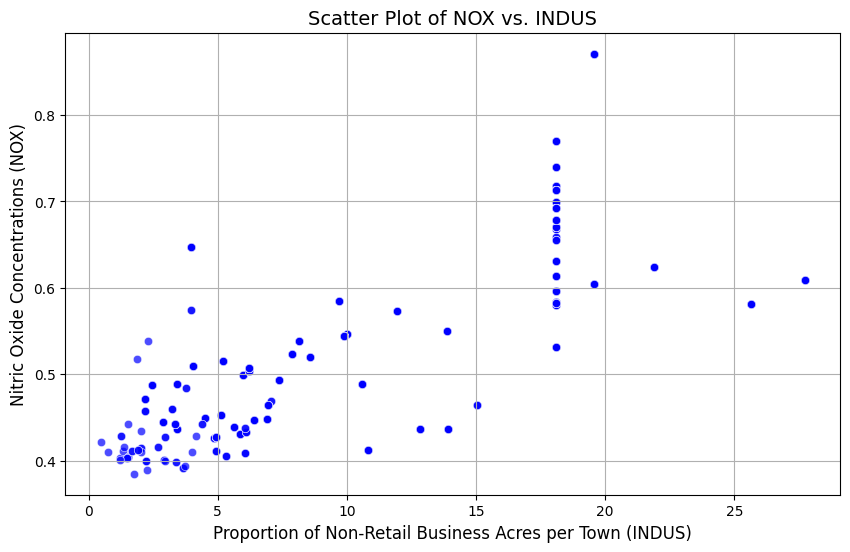

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=boston_df['INDUS'], y=boston_df['NOX'], color='blue', alpha=0.7)
plt.title('Scatter Plot of NOX vs. INDUS', fontsize=14)
plt.xlabel('Proportion of Non-Retail Business Acres per Town (INDUS)', fontsize=12)
plt.ylabel('Nitric Oxide Concentrations (NOX)', fontsize=12)
plt.grid(True)
plt.show()


The data indicate a correlation between the INDUS and NOX concentration. An increase of INDUX increases the NOX concentration

In [19]:
correlation = boston_df['INDUS'].corr(boston_df['NOX'])
print(f"Correlation between INDUS and NOX: {correlation:.4f}")

Correlation between INDUS and NOX: 0.7637


Also , the correlation between INDUS and NOX is approximately 0.7633, indicating a strong positive correlation. This suggests that as the proportion of non-retail business acres per town increases, the nitric oxide concentrations also tend to increase.

Task 2.5 Create a histogram for the pupil to teacher ratio variable

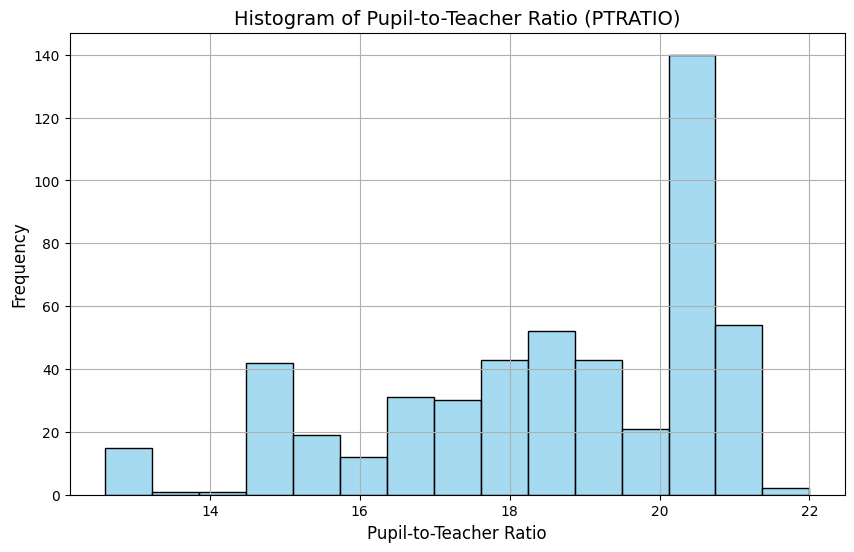

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(boston_df['PTRATIO'], bins=15, kde=False, color='skyblue')
plt.title('Histogram of Pupil-to-Teacher Ratio (PTRATIO)', fontsize=14)
plt.xlabel('Pupil-to-Teacher Ratio', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

Task 3.1 Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)


In [23]:
from scipy.stats import ttest_ind

chas_1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
chas_0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

print("Null Hypothesis (H0): There is no significant difference in the median value of houses bounded by the Charles River.")
print("Alternative Hypothesis (H1): There is a significant difference in the median value of houses bounded by the Charles River.")
print('------------Analysis------------')

t_stat, p_value = ttest_ind(chas_1, chas_0, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

print('------------Interpretation------------')
if p_value < 0.05:
    print("There is a significant difference in the median value of houses bounded by the Charles River.")
else:
    print("There is no significant difference in the median value of houses bounded by the Charles River.")

Null Hypothesis (H0): There is no significant difference in the median value of houses bounded by the Charles River.
Alternative Hypothesis (H1): There is a significant difference in the median value of houses bounded by the Charles River.
------------Analysis------------
T-Statistic: 3.1133
P-Value: 0.0036
------------Interpretation------------
There is a significant difference in the median value of houses bounded by the Charles River.


In [24]:
from scipy.stats import f_oneway

age_groups = boston_df.groupby('AGE_GROUP')['MEDV']

print("Null Hypothesis (H0): There is no difference in the median values of houses (MEDV) for each age group.")
print("Alternative Hypothesis (H1): There is a difference in the median values of houses (MEDV) for at least one age group.")
print('------------Analysis------------')

anova_result = f_oneway(*[group for _, group in age_groups])

print(f"F-Statistic: {anova_result.statistic:.4f}")
print(f"P-Value: {anova_result.pvalue:.4f}")

print('------------Interpretation------------')
if anova_result.pvalue < 0.05:
    print("There is a significant difference in the median values of houses (MEDV) for at least one age group.")
else:
    print("There is no significant difference in the median values of houses (MEDV) for the age groups.")

Null Hypothesis (H0): There is no difference in the median values of houses (MEDV) for each age group.
Alternative Hypothesis (H1): There is a difference in the median values of houses (MEDV) for at least one age group.
------------Analysis------------
F-Statistic: 36.4076
P-Value: 0.0000
------------Interpretation------------
There is a significant difference in the median values of houses (MEDV) for at least one age group.


C:\Users\adeli\AppData\Local\Temp\ipykernel_11296\34552260.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = boston_df.groupby('AGE_GROUP')['MEDV']


In [26]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(boston_df['INDUS'], boston_df['NOX'])

print("Null Hypothesis (H0): There is no relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS).")
print("Alternative Hypothesis (H1): There is a relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS).")
print('------------Analysis------------')
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"P-Value: {p_value:.4f}")

print('------------Interpretation------------')
if p_value < 0.05:
    print("There is a significant relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS).")
else:
    print("There is no significant relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS).")

Null Hypothesis (H0): There is no relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS).
Alternative Hypothesis (H1): There is a relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS).
------------Analysis------------
Pearson Correlation Coefficient: 0.7637
P-Value: 0.0000
------------Interpretation------------
There is a significant relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS).


In [29]:
import statsmodels.api as sm

X = boston_df['DIS']
y = boston_df['MEDV']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

if model.pvalues['DIS'] < 0.05:
    print(f"An additional weighted distance to the five Boston employment centres has a statistically significant impact on the median value of owner-occupied homes. The coefficient is {model.params['DIS']:.4f}, indicating that for each additional unit of distance, the median value changes by this amount.")
else:
    print("An additional weighted distance to the five Boston employment centres does not have a statistically significant impact on the median value of owner-occupied homes.")
print(model.summary())

An additional weighted distance to the five Boston employment centres has a statistically significant impact on the median value of owner-occupied homes. The coefficient is 1.0916, indicating that for each additional unit of distance, the median value changes by this amount.
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Thu, 01 May 2025   Prob (F-statistic):           1.21e-08
Time:                        22:06:36   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Ty